# 乳癌資料庫預測SVM分類
>使用scikit-learn 機器學習套件裡的SVR演算法

* (一)引入函式庫及內建乳癌資料集<br>
引入之函式庫如下<br>
sklearn.datasets: 用來匯入內建之乳癌資料集`datasets.load_breast_cancer()`<br>
sklearn.SVM (Support Vector Machine) : 支持向量積回歸分析之演算法<br>
matplotlib.pyplot: 用來繪製影像

In [1]:
from sklearn import svm
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## Step1. 下載資料

In [2]:
breast_cancer=datasets.load_breast_cancer()

In [3]:
print(breast_cancer.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
print(breast_cancer.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [5]:
print(breast_cancer.target_names)

['malignant' 'benign']


In [7]:
X = breast_cancer.data
y = breast_cancer.target
print(X.shape)
print(y.shape)
# 569筆病患資料，30個特徵

(569, 30)
(569,)


In [8]:
print(y[:5])

[0 0 0 0 0]


## Step2. 區分訓練集與測試集

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)
print(X_train.shape)
print(X_test.shape)

(398, 30)
(171, 30)


In [12]:
# SVM對資料尺度非常敏感，一定要做Standardization
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [19]:
X_train_std = scaler.transform(X_train) # 標準化訓練集

In [20]:
X_test_std = scaler.transform(X_test) # 標準化測試集

In [22]:
print(X_train_std[:5]) # Z-score

[[-0.28192196  0.66174195 -0.37431608 -0.33689878 -2.40393646 -1.59628412
  -1.06475506 -1.18589602 -1.54154773 -1.4898222  -0.83612463 -0.13949461
  -0.89185888 -0.56053571 -1.22583434 -1.27625604 -0.92600125 -1.60351416
  -0.49468046 -1.06310378 -0.43513446  0.49912848 -0.53409796 -0.44617596
  -2.26809968 -1.40377966 -1.23351565 -1.57163052 -0.987646   -1.43016122]
 [ 0.18650131 -1.22186345  0.28233605  0.02626846  0.48323216  1.50768183
   0.68403182  0.38034885  1.00094703  1.52069155  0.60089793  0.52047749
   1.09751023  0.24969787  1.04123323  1.51793139  0.62817481  0.71130297
   0.73460642  0.61597061  0.0620547  -1.20722806  0.2216053  -0.10643083
  -0.06670588  0.68018552  0.21040397 -0.05396602 -0.13691022  0.38685223]
 [ 0.19207778  0.51772843  0.17417681  0.02850851  1.23721067  0.61743218
   0.49257438  0.84729207  0.78385992  0.62252723  0.12484328 -0.12518628
  -0.01188348  0.03369712 -1.14252186  0.18786967 -0.19347224  0.20014462
  -0.25355111  0.11476557  0.3470289

## Step3. 建模

In [23]:
model = svm.SVC(kernel='rbf') #建立SVM模型

In [24]:
model.fit(X_train_std, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Step4. 預測

```

```


In [39]:
y_pred = model.predict(X_test_std)
print(y_pred[:10])

[1 1 1 0 1 1 1 0 1 1]


In [40]:
print(type(y_test))
print(y_test.shape)

<class 'numpy.ndarray'>
(171,)


In [41]:
print(type(y_pred))
print(y_pred.shape)

<class 'numpy.ndarray'>
(171,)


## Step5. 準確度分析

In [61]:
#繪製Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import matplotlib.pyplot as plt

# 產生混淆矩陣，比較真實答案(y_test)與預測值(y_pred)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 64   2]
 [  1 104]]


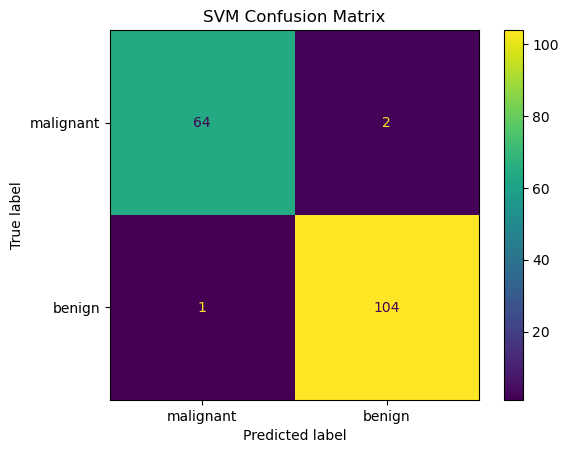

In [62]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=breast_cancer.target_names)
disp.plot()
plt.title('SVM Confusion Matrix')
plt.show()
# TN: 64位惡性腫瘤病患，SVM成功判斷為惡性
# FP: 偽陽性，有2位
# FN: 偽陰性，1位
# TP: 104位良性病患

In [63]:
# 真實例判斷正確率
acc = accuracy_score(y_test, y_pred)
print('Accuracy =', acc)

Accuracy = 0.9824561403508771


In [64]:
# 這是在算良性腫瘤預測精準率，而不是惡性，因為precisoin_score預設pos_lable=1
precision = precision_score(y_test,y_pred)
print('Precision =', precision)

Precision = 0.9811320754716981


In [65]:
# 惡性腫瘤預測精準率 (64/64+1) = 0.9846...
precision_malignant = precision_score(y_test, y_pred, pos_label=0)
print('Precision Malignant =', precision_malignant)

Precision Malignant = 0.9846153846153847


In [54]:
# Recall: 所有良性患者中，有多少機率被找出來
recall = recall_score(y_test, y_pred)
print('Recall =', recall)

Recall = 0.9904761904761905


In [66]:
# 所有真正惡性患者中，有多少機率被找出來Recall_malignant
recall_malignant = recall_score(y_test, y_pred, pos_label=0)
print('Recall_Malignant =', recall_malignant)

Recall_Malignant = 0.9696969696969697
